In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../data/temp_electricity.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [3]:
df["year"] = df["Datetime"].dt.year
df["month"] = df["Datetime"].dt.month
df["dayofweek"] = df["Datetime"].dt.dayofweek  # 0=Mon
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

In [4]:
df.head()

,Datetime,Consommation,Regions,Nature,year,month,day,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,GWETROOT,...,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,WD10M,WS10M,WS2M,insee_dep,dayofweek,is_weekend
0,2020-01-01,403787.0,Auvergne-Rhône-Alpes,Données définitives,2020,1,1,5.39,6.80,0.68,...,0.81,5.26,-1.36,6.62,314.6,1.44,0.82,83,2,0
1,2020-01-02,443531.0,Auvergne-Rhône-Alpes,Données définitives,2020,1,2,4.78,6.45,0.68,...,2.44,8.35,-0.89,9.24,200.2,3.64,2.26,83,3,0
2,2020-01-03,434626.0,Auvergne-Rhône-Alpes,Données définitives,2020,1,3,3.80,6.38,0.68,...,3.94,8.16,1.49,6.67,246.6,3.21,1.91,83,4,0
3,2020-01-04,395169.0,Auvergne-Rhône-Alpes,Données définitives,2020,1,4,3.91,6.99,0.68,...,3.18,5.62,-0.64,6.26,335.6,4.34,2.77,83,5,1
4,2020-01-05,400169.0,Auvergne-Rhône-Alpes,Données définitives,2020,1,5,5.85,7.13,0.67,...,0.77,4.06,-1.25,5.31,354.9,3.75,2.43,83,6,1


In [ ]:
#Descriptive Statistics

In [12]:
display(df["Consommation"].describe())
display(df["T2M"].describe())
display(df.groupby("Regions")[["Consommation", "T2M"]].describe())

count     21924.000000
mean     204433.967843
std       94293.008281
min       58376.000000
25%      125892.500000
50%      191000.500000
75%      262712.500000
max      624804.000000
Name: Consommation, dtype: float64

count    21924.000000
mean        12.013618
std          6.930725
min         -8.040000
25%          6.827500
50%         11.635000
75%         17.380000
max         33.310000
Name: T2M, dtype: float64

Consommation                                         \
                               count           mean           std       min   
Regions                                                                       
Auvergne-Rhône-Alpes          1827.0  342596.859880  64746.136845  234684.0   
Bourgogne-Franche-Comté       1827.0  109851.909141  22470.589562   67161.0   
Bretagne                      1827.0  119285.205802  27838.740250   72725.0   
Centre-Val de Loire           1827.0   97308.937603  22967.548838   58376.0   
Grand-Est                     1827.0  234006.535851  42286.268818  154087.0   
Hauts-de-France               1827.0  258629.059661  42353.482796  144157.0   
Ile-de-France                 1827.0  359618.373837  82920.332118  216397.0   
Normandie                     1827.0  144454.072797  30962.329042   64669.0   
Nouvelle-Aquitaine            1827.0  228669.166940  47832.733907  156845.0   
Occitanie                     1827.0  201205.998358  41757.643674  137804.0   
PACA                          1827.0  215320.491516  35987.132874  128984.0   
Pays-de-la-Loire              1827.0  142261.002737  33549.924484   58845.0   

                                                                    T2M  \
                              25%       50%       75%       max   count   
Regions                                                                   
Auvergne-Rhône-Alpes     297004.0  321116.0  388601.0  532256.0  1827.0   
Bourgogne-Franche-Comté   94505.5  103790.0  125636.0  176522.0  1827.0   
Bretagne                 100457.5  109461.0  139713.0  230009.0  1827.0   
Centre-Val de Loire       79503.5   89968.0  113728.5  174310.0  1827.0   
Grand-Est                203241.0  224851.0  263915.0  358770.0  1827.0   
Hauts-de-France          227054.0  248745.0  289640.0  397412.0  1827.0   
Ile-de-France            294165.0  336197.0  419749.5  624804.0  1827.0   
Normandie                120594.5  136120.0  167809.0  281907.0  1827.0   
Nouvelle-Aquitaine       193791.0  210637.0  260424.0  396253.0  1827.0   
Occitanie                169991.0  187339.0  227507.0  364705.0  1827.0   
PACA                     187152.0  205260.0  238816.0  346351.0  1827.0   
Pays-de-la-Loire         120918.0  131634.0  164698.5  261579.0  1827.0   

                                                                          \
                              mean       std   min    25%    50%     75%   
Regions                                                                    
Auvergne-Rhône-Alpes     11.224280  7.677251 -8.04  5.065  10.73  17.440   
Bourgogne-Franche-Comté  11.714488  7.440638 -5.73  5.890  11.32  17.815   
Bretagne                 12.020805  4.862264 -2.42  8.570  11.82  15.780   
Centre-Val de Loire      12.781959  7.050835 -4.45  7.540  12.50  18.445   
Grand-Est                10.876519  7.377570 -7.07  5.255  10.51  16.915   
Hauts-de-France          11.063864  6.034092 -5.55  6.600  10.90  16.060   
Ile-de-France            12.107039  6.740356 -5.19  7.145  11.86  17.580   
Normandie                11.301762  6.059701 -4.67  6.865  11.12  16.120   
Nouvelle-Aquitaine       13.373021  7.329859 -2.88  7.680  12.68  19.245   
Occitanie                13.305200  7.313162 -3.96  7.635  12.51  19.205   
PACA                     11.574587  7.740083 -6.06  5.085  10.53  18.005   
Pays-de-la-Loire         12.819896  6.368935 -3.24  8.260  12.65  17.890   

                                
                           max  
Regions                         
Auvergne-Rhône-Alpes     30.09  
Bourgogne-Franche-Comté  29.38  
Bretagne                 27.79  
Centre-Val de Loire      31.46  
Grand-Est                29.47  
Hauts-de-France          26.22  
Ile-de-France            30.24  
Normandie                27.48  
Nouvelle-Aquitaine       33.31  
Occitanie                32.38  
PACA                     29.20  
Pays-de-la-Loire         30.90

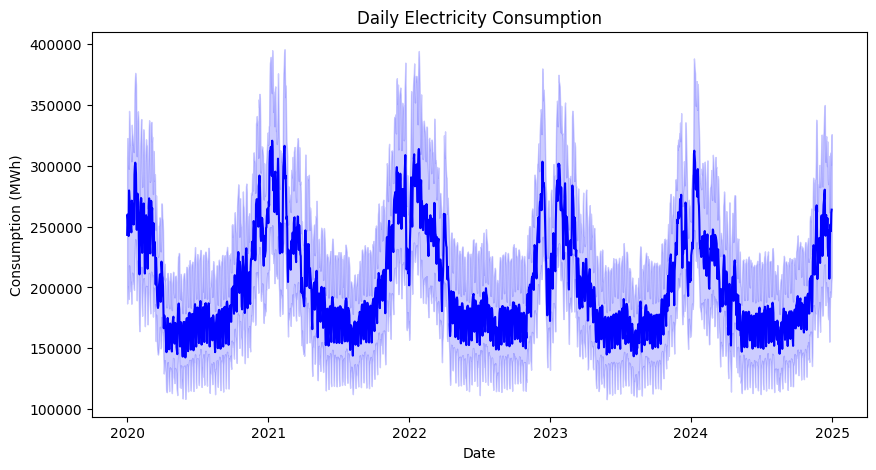

In [13]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x="Datetime", y="Consommation", color='blue')
plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption (MWh)")
plt.show()

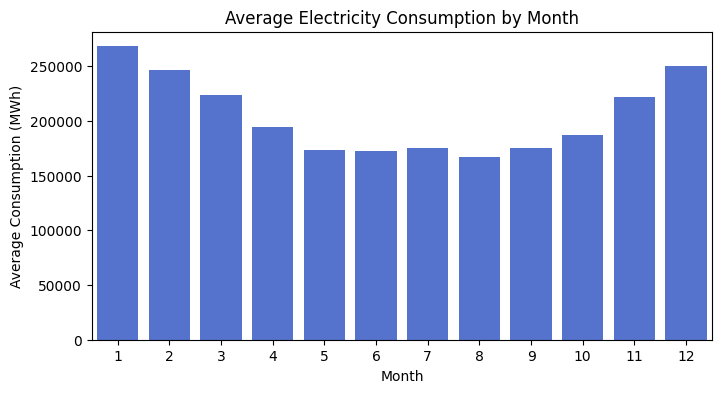

In [14]:
monthly_avg = df.groupby("month")["Consommation"].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, color="royalblue")
plt.title("Average Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MWh)")
plt.show()

/tmp/ipykernel_10948/2247789357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_mean.values, y=region_mean.index, palette="viridis")


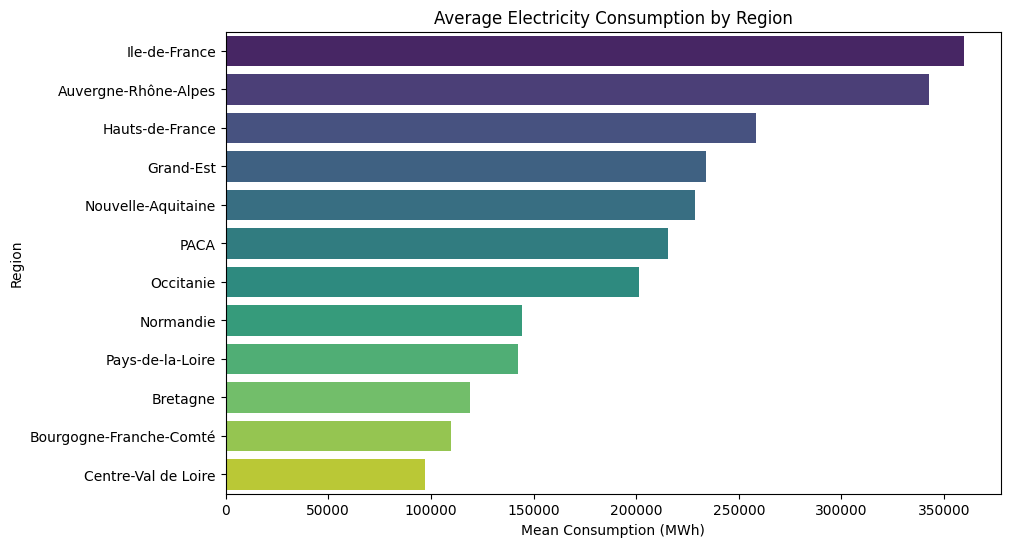

In [15]:
region_mean = df.groupby("Regions")["Consommation"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=region_mean.values, y=region_mean.index, palette="viridis")
plt.title("Average Electricity Consumption by Region")
plt.xlabel("Mean Consumption (MWh)")
plt.ylabel("Region")
plt.show()

/tmp/ipykernel_10948/26673818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Regions", y="T2M", palette="coolwarm")


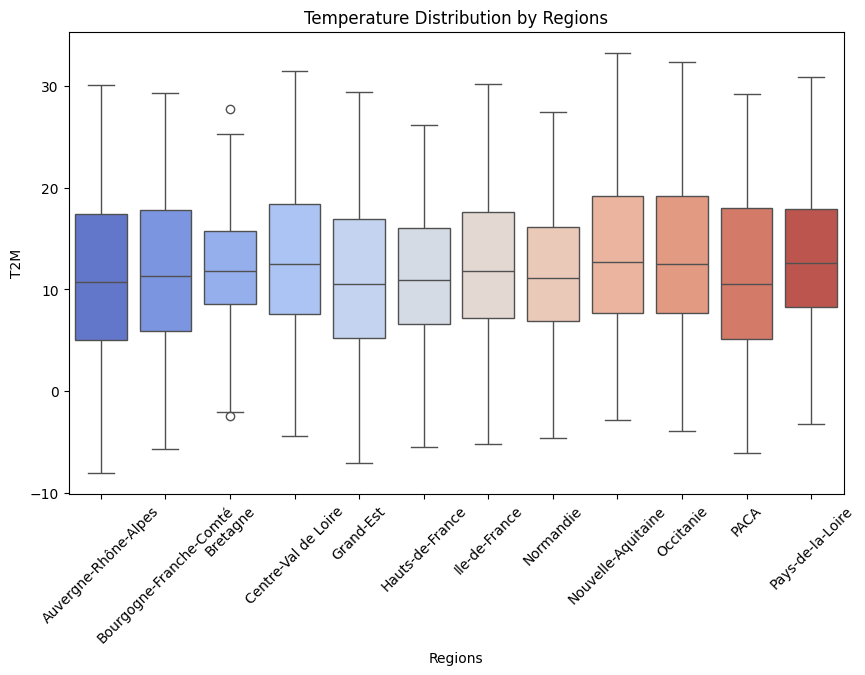

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Regions", y="T2M", palette="coolwarm")
plt.title("Temperature Distribution by Regions")
plt.xticks(rotation=45)
plt.show()

# 📊 Descriptive Statistics: Electricity Consumption and Temperature in France (2020–2024)

## 1. Overview of Key Variables

We analyze two main variables across the 12 metropolitan regions of France:

- **Electricity consumption** (`Consommation`, in MWh)  
- **Daily mean temperature** (`T2M`, in °C), sourced from the NASA POWER API  

The dataset forms a daily panel from **2020 to 2024**, totaling **21,924 observations**.

---

## 2. National-Level Descriptive Statistics

### **Electricity Consumption (All Regions Pooled)**

| Statistic | Value |
|----------|--------|
| Count | 21,924 |
| Mean | ~204,434 MWh |
| Standard Deviation | ~94,293 MWh |
| Minimum | 58,376 MWh |
| Maximum | 624,804 MWh |

**Interpretation:**  
Daily consumption varies greatly across the dataset. The difference between the minimum and maximum values reflects substantial seasonal fluctuations, with peaks typically occurring in winter due to heating demand.

---

### **Daily Mean Temperature (All Regions Pooled)**

| Statistic | Value |
|----------|--------|
| Mean | ~12.0°C |
| Standard Deviation | ~6.9°C |
| Minimum | –8.0°C |
| Maximum | 33.3°C |

**Interpretation:**  
France experiences a wide range of temperatures, from very cold winter conditions to intense summer heat. This broad variability is useful for examining how temperature affects electricity demand.

---

## 3. Regional Descriptive Statistics

Descriptive statistics by region highlight both climatic and consumption differences across France.

### **Electricity Consumption by Region**

- **Regions with the highest average consumption:**  
  - Île-de-France (~360,000 MWh/day)  
  - Hauts-de-France  
  - Grand-Est  
  - Auvergne-Rhône-Alpes  
  These regions are larger and experience colder winters, which increases energy demand for heating.

- **Regions with the lowest average consumption:**  
  - Centre-Val de Loire (~97,000 MWh/day)  
  - Bourgogne-Franche-Comté  

### **Temperature by Region**

- **Warmest regions (highest average T2M):**  
  - Nouvelle-Aquitaine (13.37°C)  
  - Occitanie (13.30°C)  

- **Coldest regions:**  
  - Grand-Est (10.88°C)  
  - Hauts-de-France (11.06°C)  
  - Normandie (11.30°C)  

**Interpretation:**  
Regional patterns show that colder regions consistently consume more electricity on average, suggesting a strong link between temperature and consumption.

---

## 4. Evidence of Seasonality

Time-series plots of consumption and temperature show clear **regular yearly patterns**:

- Electricity consumption **peaks in winter** and **drops in summer**.
- Temperature follows the opposite cycle.
- These patterns repeat consistently across each year from 2020 to 2024.

**Interpretation:**  
The presence of a stable, repeating annual pattern confirms a strong **seasonal effect** in electricity consumption, largely driven by temperature variations.

---

## 5. Key Findings from the Descriptive Analysis

- Electricity consumption and temperature vary widely both across time and regions.
- Colder regions show systematically higher consumption, consistent with heating needs.
- The dataset exhibits strong seasonality, making temperature a natural explanatory variable.
- These observations justify further analysis through **correlation** and **regression modeling** to quantify the temperature–consumption relationship.

---



Note that Île-de-France is not the coldest region but displays the highest electricity consumption. This difference is not due to temperature alone, but to structural factors such as population density and economic activity. These factors explain the higher baseline level of consumption, while our analysis focuses specifically on how temperature variations affect consumption within each region.